In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv
import os
load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("Google API Key is set.")
else:
    raise ValueError("Google API Key is not set.")

Google API Key is set.


In [2]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

### **Pydantic LLM Schema**

In [3]:
from pydantic import BaseModel, Field
from typing import List, TypedDict, Literal

class llm_schema(BaseModel):
    funny_flag: Literal["funny","not funny"] = Field(description="Whether the joke is funny or not")
    feedback: str = Field(description="Feedback on the joke")

llm_with_schema = llm.with_structured_output(llm_schema)

### **Graph Schema**

In [4]:
class graph_schema(TypedDict):

    topic: str
    joke: str
    funny_flag: str
    feedback: str
    max_iterations: int

### **Nodes**

In [5]:
def generate_node(state: graph_schema) -> graph_schema:
    

    topic = state['topic']

    if state['feedback']: # Not first iteration, generate a joke based on feedback
        response = llm.invoke(f"Please modify the following joke {state['joke']} based on the following feedback: {state['feedback']}") 
    else: # First iteration, generate a joke
        response = llm.invoke("Create only one joke about the following topic: " + topic)

    
    state['joke'] = response.content 
    return state

In [6]:
def evaluate_node(state: graph_schema) -> graph_schema: 

    joke = state['joke']
    iteration = state['max_iterations']

    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a comedy critic. Your job is to evaluate the following joke and provide feedback on how to make it funnier."),
        ("user", f"Evaluate the following joke: {joke}\nRespond with 'funny' or 'not_funny' and provide feedback if it's not funny.")
    ])

    chain = prompt | llm_with_schema
    response = chain.invoke({"joke": joke})

    state['funny_flag'] = response.funny_flag
    state['feedback'] = response.feedback
    state['max_iterations'] = iteration + 1

    return state

### **Conditional Edge Function**

In [7]:
def check_iteration(state: graph_schema) -> str:

    iteration = state['max_iterations']

    if iteration <= 5 and state['funny_flag'] != "funny":
        return "evaluate_node"
    else:
        return "end"

### **Create State Graph**

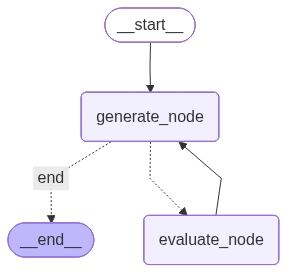

In [8]:
from langgraph.graph import StateGraph, START, END 


graph = StateGraph(graph_schema)

graph.add_node("generate_node", generate_node)
graph.add_node("evaluate_node", evaluate_node)

graph.add_edge(START, "generate_node")
graph.add_conditional_edges("generate_node", check_iteration, {"evaluate_node": "evaluate_node", "end": END})
graph.add_edge("evaluate_node", "generate_node")
graph.add_edge("generate_node", END)

evaluator_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(evaluator_graph.get_graph().draw_mermaid_png())

In [ ]:
for chunk in evaluator_graph.stream(
    {
        "topic": "Cars",
        "joke": "",
        "funny_flag": "",
        "feedback": "",
        "max_iterations": 0
    },
    stream_mode="updates"
):
    print(chunk)